# Task 1 — A* Search for 8-Puzzle

**Improvements over original:**
- `manhattan_distance`: pre-builds a `{tile: (r,c)}` lookup dict → **O(9)** per call instead of **O(81)**
- `get_blank_pos`: single-pass `next()` generator instead of nested loop
- `get_dest_pos`: dict-based action→delta map (no repeated `if`s)
- `a_star_search`: clean retry loop instead of `try/except` hack
- `draw_tree`: consistent path-only vs full-tree rendering
- Cells split so graph render never blocks `input()`

## 1. Imports

In [1]:
from __future__ import annotations
from copy import deepcopy
from graphviz import Digraph
import heapq
import random
import time
import IPython.display as IPd

## 2. `Node` class

In [2]:
# Direction -> (row_delta, col_delta) for the BLANK tile's movement
_DELTA: dict[str, tuple[int, int]] = {
    'L': ( 0,  1),   # blank moves left  -> tile to the RIGHT slides left
    'R': ( 0, -1),
    'U': ( 1,  0),
    'D': (-1,  0),
}

# Pairs that auto-swap when adjacent after a blank move
_SWAP_PAIRS: frozenset[tuple[int, int]] = frozenset([(1, 3), (3, 1), (2, 4), (4, 2)])


class Node:
    """Search-tree node for the 8-puzzle.

    Attributes
    ----------
    state     : list[list[int]]  3x3 grid (0 = blank)
    action    : str | None       move that produced this state
    parent    : Node | None
    path_cost : int              g(n)
    """

    __slots__ = ('state', 'id', 'action', 'parent', 'path_cost')

    def __init__(self, state: list, action: str | None = None,
                 parent: 'Node | None' = None, path_cost: int = 0) -> None:
        self.state     = state
        self.action    = action
        self.parent    = parent
        self.path_cost = path_cost
        self.id        = self._make_id()   # stable string key for closed-set

    # ----------------------------------------------------------------- helpers
    def _make_id(self) -> str:
        """Flat tuple string — cheaper to build & compare than the multi-line repr."""
        return ''.join(str(cell) for row in self.state for cell in row)

    def __str__(self) -> str:
        """Multi-line label used inside graphviz nodes."""
        return '\n'.join(
            ''.join('_' if c == 0 else str(c) for c in row)
            for row in self.state
        )

    def __lt__(self, other: 'Node') -> bool:
        return self.path_cost < other.path_cost

    # --------------------------------------------------------- blank position
    def get_blank_pos(self, state: list) -> tuple[int, int]:
        """Return (row, col) of the blank cell — O(n) single pass."""
        return next(
            (i, j)
            for i, row in enumerate(state)
            for j, cell in enumerate(row)
            if cell == 0
        )

    # ---------------------------------------------------------- successors
    def get_successors(self) -> list['Node']:
        successors = []
        for action in _DELTA:
            new_state = self._apply_action(action, deepcopy(self.state))
            if new_state is not None:
                successors.append(Node(new_state, action, self, self.path_cost + 1))
        return successors

    def _apply_action(self, action: str, state: list) -> list | None:
        pi, pj = self.get_blank_pos(state)
        dr, dc = _DELTA[action]
        ni, nj = pi + dr, pj + dc

        if not (0 <= ni < 3 and 0 <= nj < 3):
            return None

        # Move blank
        state[pi][pj], state[ni][nj] = state[ni][nj], state[pi][pj]

        # Auto-swap rule: (1<->3) and (2<->4) if adjacent after the move
        for i in range(3):          # horizontal neighbours
            for j in range(2):
                if (state[i][j], state[i][j+1]) in _SWAP_PAIRS:
                    state[i][j], state[i][j+1] = state[i][j+1], state[i][j]
        for i in range(2):          # vertical neighbours
            for j in range(3):
                if (state[i][j], state[i+1][j]) in _SWAP_PAIRS:
                    state[i][j], state[i+1][j] = state[i+1][j], state[i][j]

        return state

    # ----------------------------------------------------------- visualize
    def draw(self, dot: Digraph) -> None:
        dot.node(self.id, str(self))
        if self.parent is not None:
            dot.edge(self.parent.id, self.id, self.action)

## 3. Goal states & helpers

In [3]:
GOAL_STATES = [
    [[1, 2, 3], [4, 5, 6], [7, 8, 0]],  # Goal 1
    [[8, 7, 6], [5, 4, 3], [2, 1, 0]],  # Goal 2
    [[0, 1, 2], [3, 4, 5], [6, 7, 8]],  # Goal 3
    [[0, 8, 7], [6, 5, 4], [3, 2, 1]],  # Goal 4
]

# Pre-build {tile: (row, col)} for each goal — used by heuristics for O(1) lookup
_GOAL_POS: list[dict[int, tuple[int, int]]] = [
    {g[i][j]: (i, j) for i in range(3) for j in range(3)}
    for g in GOAL_STATES
]

def is_goal(state: list) -> bool:
    return any(state == g for g in GOAL_STATES)

## 4. Heuristic functions h(n)

### 4a. Manhattan distance
**Admissible**: each tile needs at least |Δrow|+|Δcol| moves to reach its goal — never overestimates.
**Consistent**: moving one tile changes its Manhattan distance by at most 1, so h(n) ≤ 1 + h(n').

In [4]:
def manhattan_distance(state: list, goal_pos: dict) -> int:
    """
    Sum of Manhattan distances of each tile from its goal position.

    Uses a pre-built {tile: (r,c)} dict for O(1) lookup per tile
    instead of an O(9) nested search — reduces per-call work from O(81) to O(9).
    """
    dist = 0
    for i, row in enumerate(state):
        for j, tile in enumerate(row):
            if tile != 0:  # skip blank
                gi, gj = goal_pos[tile]   # O(1)
                dist += abs(i - gi) + abs(j - gj)
    return dist

### 4b. Misplaced tiles
**Admissible**: every misplaced tile needs at least 1 move — never overestimates.
**Consistent**: one move fixes at most 1 misplacement, so h(n) ≤ 1 + h(n').

In [5]:
def misplaced_tiles(state: list, goal_pos: dict) -> int:
    """
    Count of tiles not in their goal position (blank excluded).
    """
    count = 0
    for i, row in enumerate(state):
        for j, tile in enumerate(row):
            if tile != 0 and goal_pos[tile] != (i, j):
                count += 1
    return count


def get_min_heuristic(state: list, heuristic_func) -> int:
    """Min heuristic over all goal states — preserves admissibility."""
    return min(heuristic_func(state, gp) for gp in _GOAL_POS)

## 5. A* search

In [6]:
def a_star_search(
    initial_state: list,
    heuristic_func,
    max_nodes: int = 10_000
) -> tuple[list | None, int, list]:
    """
    A* search for the 8-puzzle.

    Returns
    -------
    (solution_path, nodes_expanded, visited_nodes)
        solution_path : list[Node] root->goal, or None if not found within max_nodes
    """
    start = Node(initial_state)

    # Priority queue entries: (f, tie_break_counter, node)
    counter   = 0
    frontier  = [(start.path_cost + get_min_heuristic(start.state, heuristic_func),
                  counter, start)]
    # g-values of nodes currently in frontier (for duplicate detection)
    frontier_g: dict[str, int] = {start.id: 0}
    closed:     set[str]       = set()

    nodes_expanded = 0
    visited_nodes  = [start]

    while frontier and nodes_expanded < max_nodes:
        _, _, node = heapq.heappop(frontier)

        if node.id in closed:
            continue

        if is_goal(node.state):
            # Reconstruct root-to-goal path
            path, cur = [], node
            while cur:
                path.append(cur)
                cur = cur.parent
            return path[::-1], nodes_expanded, visited_nodes

        closed.add(node.id)
        nodes_expanded += 1

        for child in node.get_successors():
            if child.id in closed:
                continue
            g = node.path_cost + 1
            # Only push if we found a cheaper path to this state
            if child.id not in frontier_g or g < frontier_g[child.id]:
                child.path_cost     = g
                frontier_g[child.id] = g
                f = g + get_min_heuristic(child.state, heuristic_func)
                counter += 1
                heapq.heappush(frontier, (f, counter, child))
                visited_nodes.append(child)

    return None, nodes_expanded, visited_nodes

## 6. Visualization

In [7]:
def draw_tree(
    nodes: list,
    max_display: int = 100,
    solution_path_only: bool = False
) -> Digraph:
    """
    Build a graphviz Digraph from a list of Nodes.

    Parameters
    ----------
    nodes             : visited_nodes list (full) or solution_path list
    max_display       : cap on nodes rendered (ignored when solution_path_only=True)
    solution_path_only: if True, walk parent chain from last node and highlight path
    """
    dot = Digraph()
    dot.attr(rankdir='TB', size='12,12', dpi='120')
    dot.node_attr.update(shape='ellipse', fontname='Courier', fontsize='10')

    if solution_path_only and nodes:
        # Walk parent chain from goal back to root
        path, cur = [], nodes[-1]
        while cur:
            path.append(cur)
            cur = cur.parent
        path.reverse()

        path_ids = {n.id for n in path}
        for node in path:
            dot.node(node.id, str(node), style='filled', fillcolor='lightblue')
            if node.parent and node.parent.id in path_ids:
                dot.edge(node.parent.id, node.id, node.action or '')
    else:
        subset = nodes[:max_display]
        for node in subset:
            node.draw(dot)
        if len(nodes) > max_display:
            dot.attr(label=f'Showing {max_display} of {len(nodes)} nodes')

    return dot


def save_and_display_graphs(
    visited_nodes: list,
    solution_path: list,
    path_only: bool = True,
    max_display: int = 100
) -> None:
    if path_only:
        g = draw_tree(solution_path, solution_path_only=True)
        g.render('solution_path', format='png', cleanup=True, view=False)
        IPd.display(IPd.Image('solution_path.png'))
    else:
        g = draw_tree(visited_nodes, max_display=max_display, solution_path_only=False)
        g.render('full_graph', format='png', cleanup=True, view=False)
        IPd.display(IPd.Image('full_graph.png'))

## 7. Utilities

In [8]:
def generate_random_puzzle(max_steps: int = 100) -> list:
    """Generate a solvable 8-puzzle state by random-walking from a goal."""
    node = Node(deepcopy(random.choice(GOAL_STATES)))
    for _ in range(max_steps):
        succs = node.get_successors()
        if succs:
            node = random.choice(succs)
    return node.state


def print_solution(solution_path: list) -> None:
    sep = '-' * 30
    print(sep)
    print(f'Solution length : {len(solution_path) - 1} moves')
    print(sep)
    for i, node in enumerate(solution_path):
        label = 'START' if node.action is None else f'Move {i}: {node.action}'
        print(f'{label}')
        for row in node.state:
            print(' '.join('_' if c == 0 else str(c) for c in row))
        print()
    print(sep)

## 8a. Solve — choose heuristic, run A*

In [9]:
# -- choose heuristic ---------------------------------------------------------
heuristic_choice = input('Choose heuristic (1: Manhattan Distance, 2: Misplaced Tiles): ').strip()
heuristic_func = manhattan_distance if heuristic_choice != '2' else misplaced_tiles
h_name = 'Manhattan Distance' if heuristic_choice != '2' else 'Misplaced Tiles'
print(f'Using: {h_name}')

# -- generate puzzle ----------------------------------------------------------
initial_state = generate_random_puzzle()
print('\nInitial state:')
for row in initial_state:
    print(' '.join('_' if c == 0 else str(c) for c in row))

# -- run A* (auto-retry with larger limit if needed) --------------------------
solution_path, nodes_expanded, visited_nodes = None, 0, []
for limit in [1_000, 5_000, 20_000]:
    solution_path, nodes_expanded, visited_nodes = a_star_search(
        initial_state, heuristic_func, max_nodes=limit
    )
    if solution_path:
        break
    print(f'Not solved within {limit} nodes, retrying...')

print(f'\nNodes expanded : {nodes_expanded}')
if solution_path:
    print(f'Solution found : {len(solution_path) - 1} moves')
    print_solution(solution_path)
else:
    print('No solution found.')

Choose heuristic (1: Manhattan Distance, 2: Misplaced Tiles): 1
Using: Manhattan Distance

Initial state:
5 6 8
4 2 7
3 1 _

Nodes expanded : 21
Solution found : 10 moves
------------------------------
Solution length : 10 moves
------------------------------
START
5 6 8
4 2 7
3 1 _

Move 1: R
5 6 8
2 4 7
3 _ 1

Move 2: D
5 6 8
2 _ 7
3 4 1

Move 3: R
5 6 8
_ 4 7
3 2 1

Move 4: D
_ 6 8
5 2 7
3 4 1

Move 5: L
6 _ 8
5 4 7
3 2 1

Move 6: L
6 8 _
5 2 7
3 4 1

Move 7: U
6 8 7
5 4 _
3 2 1

Move 8: R
6 8 7
5 _ 4
3 2 1

Move 9: R
6 8 7
_ 5 4
3 2 1

Move 10: D
_ 8 7
6 5 4
3 2 1

------------------------------


## 8b. Visualize search graph

Show solution path only? (yes/no): yes
Max nodes to display (e.g. 100): 1000


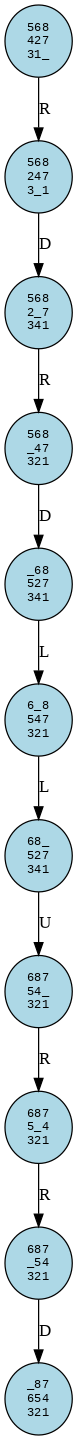

In [10]:
# -- visualization (separate cell so input() never clashes with rendering) ----
if solution_path:
    path_only  = input('Show solution path only? (yes/no): ').strip().lower() == 'yes'
    max_disp   = input('Max nodes to display (e.g. 100): ').strip()
    max_disp   = int(max_disp) if max_disp.isdigit() and int(max_disp) > 0 else 100

    save_and_display_graphs(visited_nodes, solution_path,
                            path_only=path_only, max_display=max_disp)
else:
    print('No solution to visualize.')

## 9. Heuristic comparison experiment

Randomize N initial states, solve with both heuristics, compare average path cost and nodes expanded.

In [11]:
def compare_heuristics(n_trials: int = 50, max_nodes: int = 5_000) -> None:
    results = {'Manhattan': {'costs': [], 'nodes': [], 'times': []},
               'Misplaced' : {'costs': [], 'nodes': [], 'times': []}}
    labels  = {'Manhattan': manhattan_distance, 'Misplaced': misplaced_tiles}

    for trial in range(n_trials):
        state = generate_random_puzzle()
        for name, fn in labels.items():
            t0   = time.perf_counter()
            path, expanded, _ = a_star_search(state, fn, max_nodes)
            elapsed = time.perf_counter() - t0
            if path:
                results[name]['costs'].append(len(path) - 1)
                results[name]['nodes'].append(expanded)
                results[name]['times'].append(elapsed)

    sep = '-' * 55
    print(sep)
    print(f'  Heuristic comparison  ({n_trials} trials, limit={max_nodes})')
    print(sep)
    fmt = '{:<12}  avg_cost={:.2f}  avg_nodes={:.1f}  avg_time={:.4f}s'
    for name, r in results.items():
        if r['costs']:
            print(fmt.format(
                name,
                sum(r['costs']) / len(r['costs']),
                sum(r['nodes']) / len(r['nodes']),
                sum(r['times']) / len(r['times'])
            ))
        else:
            print(f'{name:<12}  no solutions found')
    print(sep)

compare_heuristics(n_trials=30)

-------------------------------------------------------
  Heuristic comparison  (30 trials, limit=5000)
-------------------------------------------------------
Manhattan     avg_cost=16.83  avg_nodes=1216.3  avg_time=0.0716s
Misplaced     avg_cost=15.10  avg_nodes=1848.6  avg_time=0.0983s
-------------------------------------------------------
